 HOSPITAL COST ESTIMATION MODEL
 Dataset loaded: 12459 records

 Features used:
   • Age
   • Gender
   • Disease
   • Hospital_Name
   • Room_Type
   • Treatment_Type
   • Length_of_Stay_(days)
   • Severity_Level

🔧 Preprocessing...
 8 features | 6 categorical

 Train: 9967 | Test: 2492

 Training Random Forest...

 MODEL TRAINED!

 ACCURACY METRICS:
   Accuracy: 46.17%
   R² Score: 0.545
   MAE: ₹178,595
   RMSE: ₹428,095

 PREDICTION ACCURACY:
   Within ±10%: 14.9%
   Within ±20%: 29.9%


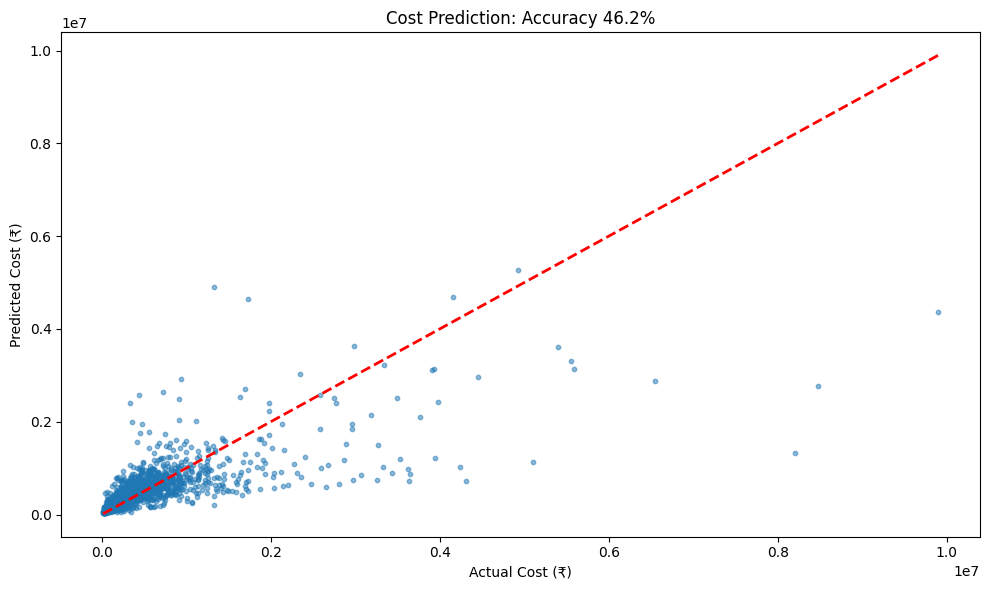


 TOP 10 IMPORTANT FEATURES
----------------------------------------------------------------------
Disease                        0.3340 █████████████████████████████████
Hospital_Name                  0.2087 ████████████████████
Age                            0.1420 ██████████████
Treatment_Type                 0.1026 ██████████
Length_of_Stay_(days)          0.0956 █████████
Severity_Level                 0.0537 █████
Room_Type                      0.0469 ████
Gender                         0.0165 █

🎉 MODEL READY! Accuracy: 46.17%

 SAMPLE PREDICTIONS

 TEST 1: ICU - PRIVATE HOSPITAL

 COST ESTIMATION

 65y Male | COVID-19
 Manipal Hospitals
  ICU | Intensive Care | 10d | Severe

 ESTIMATED COST RANGE:
   Minimum:  ₹ 1,689,000
   Expected: ₹ 1,987,000
   Maximum:  ₹ 2,285,100

   ₹1,689,000 ◄───[₹1,987,000]───► ₹2,285,100

 Very High Cost

 Model Accuracy: 46.2%


 TEST 2: GENERAL WARD - GOVERNMENT

 COST ESTIMATION

 42y Female | Dengue
 Government General Hospital
  General | Ther

In [8]:
# ===========================
# HOSPITAL COST ESTIMATION MODEL - COMPLETE
# Predicts: Cost Range (Min - Max) with Accuracy
# ===========================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" HOSPITAL COST ESTIMATION MODEL")
print("=" * 70)

# ===========================
# 1. LOAD DATA
# ===========================
df = pd.read_csv('Cost_Estimation_DS.csv')
print(f" Dataset loaded: {df.shape[0]} records\n")

# ===========================
# 2. FEATURE SELECTION
# ===========================
exclude_cols = ['Insurance_Covered_(₹)', 'Out_of_Pocket_Expense_(₹)',
                'Follow_Up_Required', 'Patient_ID', 'Doctor_Name',
                'Admission_Date', 'Discharge_Date', 'City', 'Cost_Category']

target_col = 'Estimated_Treatment_Cost_(₹)'
feature_cols = [col for col in df.columns if col not in exclude_cols + [target_col]]

print(" Features used:")
for col in feature_cols:
    print(f"   • {col}")

# ===========================
# 3. PREPROCESSING
# ===========================
print("\n🔧 Preprocessing...")

df_model = df[feature_cols + [target_col]].copy()

# Handle missing values
for column in df_model.columns:
    if column == target_col:
        continue
    if df_model[column].dtype == 'object':
        mode_val = df_model[column].mode()[0] if len(df_model[column].mode()) > 0 else 'Unknown'
        df_model[column].fillna(mode_val, inplace=True)
    else:
        df_model[column].fillna(df_model[column].median(), inplace=True)

# Encode categorical variables
label_encoders = {}
categorical_columns = []

for column in df_model.columns:
    if column == target_col:
        continue
    if df_model[column].dtype == 'object':
        le = LabelEncoder()
        df_model[column] = le.fit_transform(df_model[column].astype(str))
        label_encoders[column] = le
        categorical_columns.append(column)

print(f" {len(feature_cols)} features | {len(categorical_columns)} categorical")

# ===========================
# 4. PREPARE DATA
# ===========================
y = df_model[target_col]
X = df_model.drop(target_col, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# ===========================
# 5. TRAIN MODEL
# ===========================
print("\n Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=25, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# ===========================
# 6. ACCURACY METRICS
# ===========================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape

print(f"\n MODEL TRAINED!")
print(f"\n ACCURACY METRICS:")
print(f"   Accuracy: {accuracy:.2f}%")
print(f"   R² Score: {r2:.3f}")
print(f"   MAE: ₹{mae:,.0f}")
print(f"   RMSE: ₹{rmse:,.0f}")

within_10 = np.sum(np.abs((y_test - y_pred) / y_test) <= 0.10) / len(y_test) * 100
within_20 = np.sum(np.abs((y_test - y_pred) / y_test) <= 0.20) / len(y_test) * 100

print(f"\n PREDICTION ACCURACY:")
print(f"   Within ±10%: {within_10:.1f}%")
print(f"   Within ±20%: {within_20:.1f}%")

# ===========================
# 7. VISUALIZATION
# ===========================
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Cost (₹)')
plt.ylabel('Predicted Cost (₹)')
plt.title(f'Cost Prediction: Accuracy {accuracy:.1f}%')
plt.tight_layout()
plt.show()

# ===========================
# 8. FEATURE IMPORTANCE
# ===========================
print(f"\n TOP 10 IMPORTANT FEATURES")
print("-" * 70)

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

for _, row in feat_imp.iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:<30} {row['importance']:.4f} {bar}")

# ===========================
# 9. PREDICTION FUNCTION
# ===========================
def predict_cost_range(age, gender, disease, hospital_name, room_type,
                      treatment_type, length_of_stay, severity_level):
    """Predict cost with min-max range"""

    patient_data = pd.DataFrame({
        'Age': [age], 'Gender': [gender], 'Disease': [disease],
        'Hospital_Name': [hospital_name], 'Room_Type': [room_type],
        'Treatment_Type': [treatment_type],
        'Length_of_Stay_(days)': [length_of_stay],
        'Severity_Level': [severity_level]
    })

    # Encode
    for col in categorical_columns:
        if col in patient_data.columns and col in label_encoders:
            try:
                patient_data[col] = label_encoders[col].transform(patient_data[col])
            except:
                patient_data[col] = 0

    # Ensure column order
    patient_data = patient_data[X.columns]

    # Get predictions from all trees
    tree_preds = [tree.predict(patient_data)[0] for tree in rf_model.estimators_]
    predicted_cost = np.mean(tree_preds)

    # Calculate range (±15%)
    min_cost = round((predicted_cost * 0.85) / 100) * 100
    max_cost = round((predicted_cost * 1.15) / 100) * 100
    predicted_cost = round(predicted_cost / 100) * 100

    # Display
    print(f"\n{'='*75}")
    print(f" COST ESTIMATION")
    print(f"{'='*75}")
    print(f"\n {age}y {gender} | {disease}")
    print(f" {hospital_name}")
    print(f"  {room_type} | {treatment_type} | {length_of_stay}d | {severity_level}")
    print(f"\n ESTIMATED COST RANGE:")
    print(f"   Minimum:  ₹{min_cost:>10,}")
    print(f"   Expected: ₹{predicted_cost:>10,}")
    print(f"   Maximum:  ₹{max_cost:>10,}")
    print(f"\n   ₹{min_cost:,} ◄───[₹{predicted_cost:,}]───► ₹{max_cost:,}")

    if predicted_cost >= 300000:
        print(f"\n Very High Cost")
    elif predicted_cost >= 150000:
        print(f"\n High Cost")
    elif predicted_cost >= 50000:
        print(f"\n Medium Cost")
    else:
        print(f"\n Low Cost")

    print(f"\n Model Accuracy: {accuracy:.1f}%")
    print(f"{'='*75}\n")

    return min_cost, predicted_cost, max_cost

print(f"\n🎉 MODEL READY! Accuracy: {accuracy:.2f}%")
print("="*70)

# ===========================
# 10. TEST PREDICTIONS
# ===========================
print("\n SAMPLE PREDICTIONS\n")

print(" TEST 1: ICU - PRIVATE HOSPITAL")
predict_cost_range(65, 'Male', 'COVID-19', 'Manipal Hospitals',
                  'ICU', 'Intensive Care', 10, 'Severe')

print("\n TEST 2: GENERAL WARD - GOVERNMENT")
predict_cost_range(42, 'Female', 'Dengue', 'Government General Hospital',
                  'General', 'Therapy', 5, 'Moderate')

print("\n COMPLETE!")
